In [2]:
# ============================================================
# Phase 4 | Cell 1: Imports + Data Load
# 04_beer_regime.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from hmmlearn import hmm

PROCESSED = '../data/processed/'
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# ── Load datasets ─────────────────────────────────────────────
model = pd.read_csv(f'{PROCESSED}master_model.csv',
                    index_col=0, parse_dates=True)
model.index = pd.to_datetime(model.index).to_period('M').to_timestamp()

phase2 = pd.read_csv(f'{PROCESSED}phase2_equilibrium.csv',
                     index_col=0, parse_dates=True)
phase2.index = pd.to_datetime(phase2.index).to_period('M').to_timestamp()

phase3 = pd.read_csv(f'{PROCESSED}phase3_feer.csv',
                     index_col=0, parse_dates=True)
phase3.index = pd.to_datetime(phase3.index).to_period('M').to_timestamp()

print("✓ Data loaded")
print(f"  master_model : {model.shape}")
print(f"  phase2       : {phase2.shape}")
print(f"  phase3       : {phase3.shape}")

# ── BEER variables — the market drivers ──────────────────────
beer_vars = {
    'inr_usd'        : 'INR/USD (dependent)',
    'real_rate_diff' : 'Real rate differential (India−US)',
    'fpi_flows_usd_mn': 'FPI flows (USD mn)',
    'dxy'            : 'Dollar index (DXY)',
    'vix'            : 'VIX (risk sentiment)',
    'brent'          : 'Brent crude',
    'fed_bs_yoy'     : 'Fed balance sheet YoY (global liquidity)',
    'us_10y_yield'   : 'US 10Y yield',
}

print(f"\n  BEER market drivers:")
for v, desc in beer_vars.items():
    if v in model.columns:
        s = model[v].dropna()
        print(f"    ✓ {v:<22} {desc}")
    else:
        print(f"    ✗ {v:<22} MISSING")

print()
print("Phase 4 build order:")
print("  4a → BEER variable exploration + correlations")
print("  4b → BEER regression (what market is pricing)")
print("  4c → Regime matrix (Oil × DXY)")
print("  4d → Markov switching (endogenous regimes)")
print("  4e → Transition probability matrix (early-warning)")
print()
print("Key Phase 4 insight to capture:")
print("  The capital-account/financial pressure that REER (Phase 2)")
print("  and FEER (Phase 3) both miss — e.g. the 2022 Fed tightening")
print("  stress — should show up clearly in the BEER layer.")

✓ Data loaded
  master_model : (255, 42)
  phase2       : (255, 8)
  phase3       : (250, 10)

  BEER market drivers:
    ✓ inr_usd                INR/USD (dependent)
    ✓ real_rate_diff         Real rate differential (India−US)
    ✓ fpi_flows_usd_mn       FPI flows (USD mn)
    ✓ dxy                    Dollar index (DXY)
    ✓ vix                    VIX (risk sentiment)
    ✓ brent                  Brent crude
    ✓ fed_bs_yoy             Fed balance sheet YoY (global liquidity)
    ✓ us_10y_yield           US 10Y yield

Phase 4 build order:
  4a → BEER variable exploration + correlations
  4b → BEER regression (what market is pricing)
  4c → Regime matrix (Oil × DXY)
  4d → Markov switching (endogenous regimes)
  4e → Transition probability matrix (early-warning)

Key Phase 4 insight to capture:
  The capital-account/financial pressure that REER (Phase 2)
  and FEER (Phase 3) both miss — e.g. the 2022 Fed tightening
  stress — should show up clearly in the BEER layer.


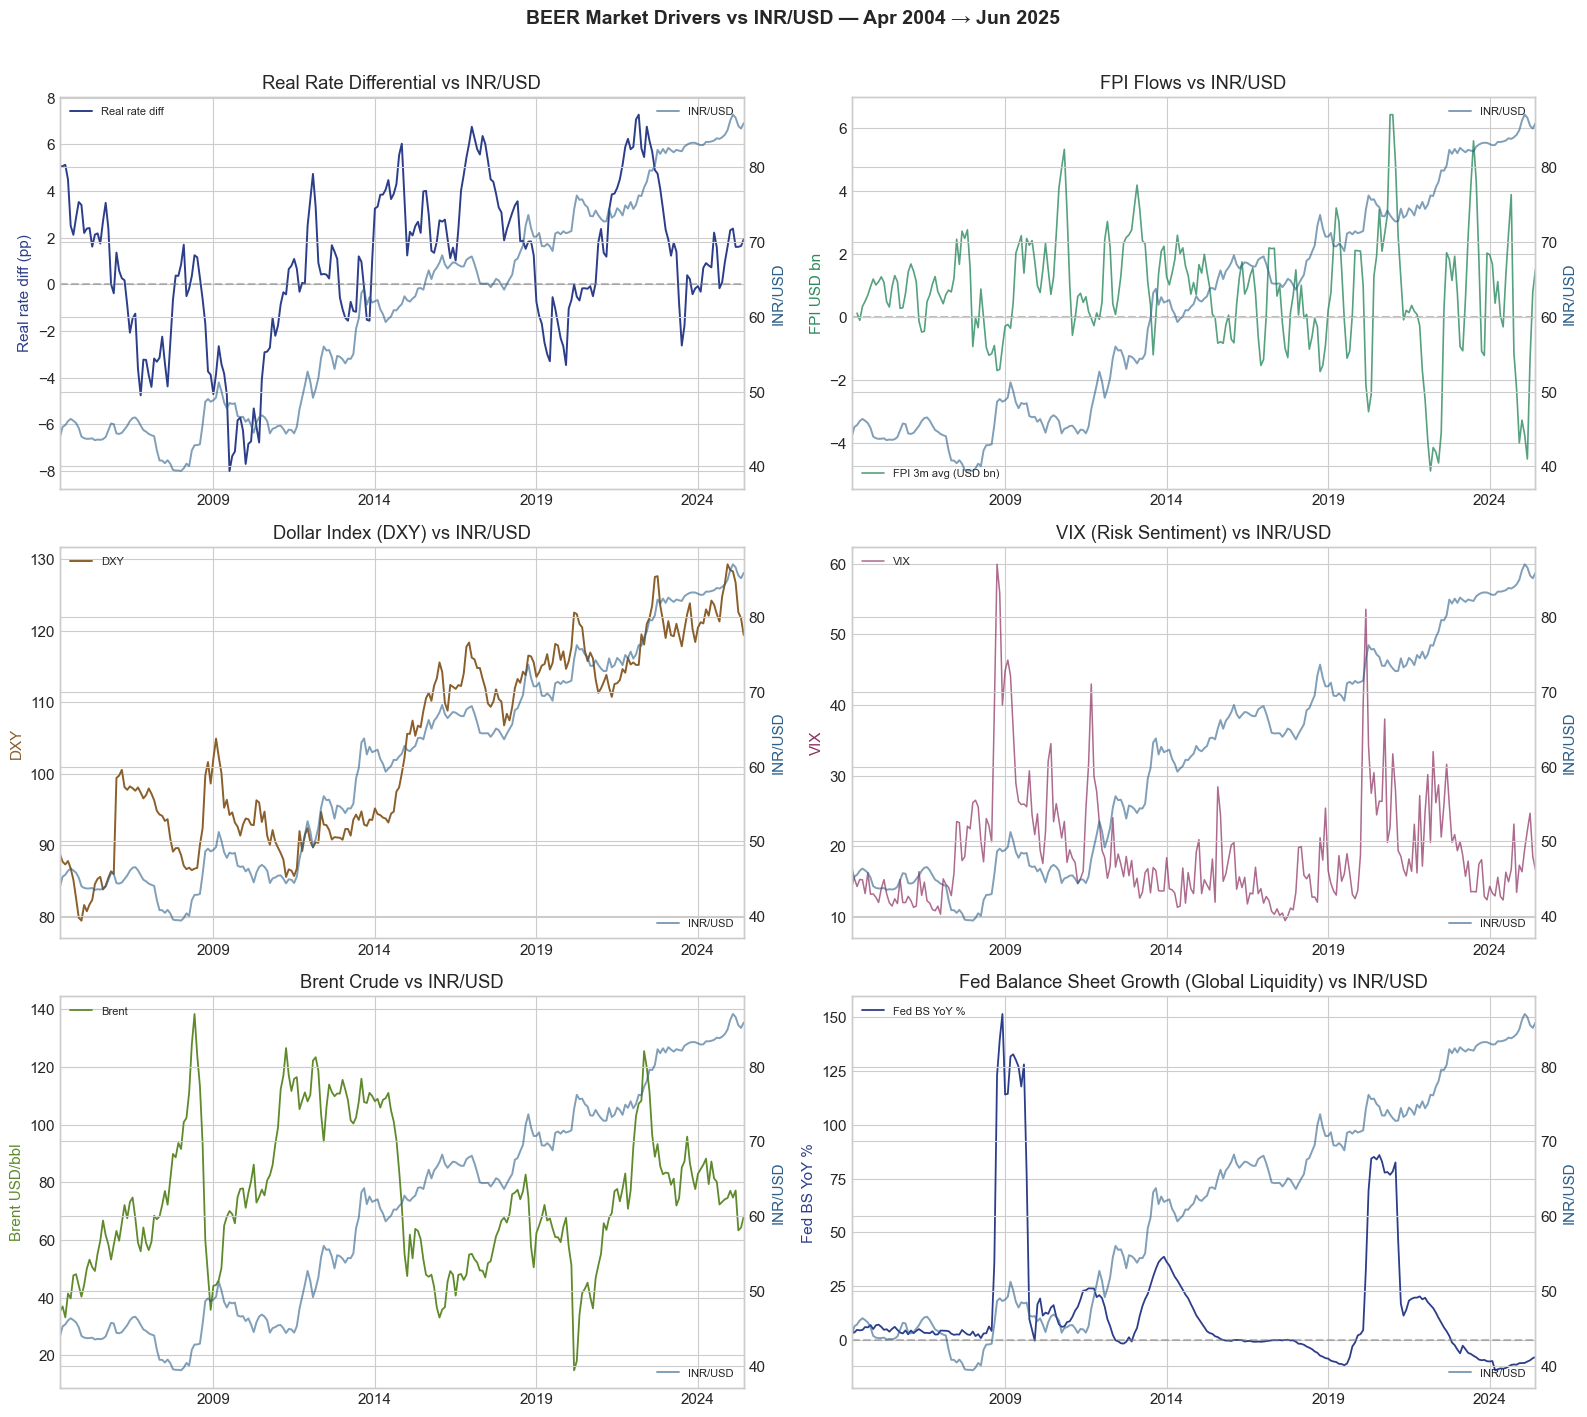

✓ Chart saved → outputs/04_beer_drivers.png

CORRELATIONS WITH INR/USD
  Driver                      Level    Δ (changes)  Expected
  ────────────────────────────────────────────────────────
  real_rate_diff             +0.378         -0.058  ⚠ higher India rates → stronger INR
  fpi_3m                     -0.190         -0.326  ✓ inflows → stronger INR
  dxy                        +0.924         +0.300  ✓ stronger USD → weaker INR
  vix                        -0.051         +0.128  ⚠ risk-off → weaker INR
  brent                      -0.098         -0.193  ⚠ higher oil → weaker INR
  fed_bs_yoy                 -0.169         +0.254  ✓ more liquidity → stronger INR
  us_10y_yield               -0.306         +0.008  ⚠ higher US yields → weaker INR

  Note: levels capture long-run co-movement (some confounded
  by shared trends); changes capture short-run market dynamics.
  The BEER regression in Cell 3 handles trends carefully.


In [3]:
# ============================================================
# Phase 4 | Cell 2: BEER Variable Exploration + Correlations
# ============================================================

df = model.copy()
df['log_inr_usd'] = np.log(df['inr_usd'])

# FPI flows: use 3-month rolling sum to smooth monthly noise
df['fpi_3m'] = df['fpi_flows_usd_mn'].rolling(3).mean()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('BEER Market Drivers vs INR/USD — Apr 2004 → Jun 2025',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Real rate differential vs INR (higher rates → stronger INR → lower INR/USD)
ax = axes[0, 0]
ax2 = ax.twinx()
df['real_rate_diff'].dropna().plot(ax=ax, color='#2c3e8a', lw=1.4, label='Real rate diff')
df['inr_usd'].plot(ax=ax2, color='#2c5f8a', lw=1.4, alpha=0.6, label='INR/USD')
ax.set_title('Real Rate Differential vs INR/USD')
ax.set_ylabel('Real rate diff (pp)', color='#2c3e8a')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.legend(fontsize=8, loc='upper left'); ax2.legend(fontsize=8, loc='upper right')

# 2. FPI flows vs INR
ax = axes[0, 1]
ax2 = ax.twinx()
(df['fpi_3m']/1000).plot(ax=ax, color='#2c8a5f', lw=1.2, label='FPI 3m avg (USD bn)', alpha=0.8)
df['inr_usd'].plot(ax=ax2, color='#2c5f8a', lw=1.4, alpha=0.6, label='INR/USD')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_title('FPI Flows vs INR/USD')
ax.set_ylabel('FPI USD bn', color='#2c8a5f')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.legend(fontsize=8, loc='lower left'); ax2.legend(fontsize=8, loc='upper right')

# 3. DXY vs INR (stronger dollar → weaker INR → higher INR/USD)
ax = axes[1, 0]
ax2 = ax.twinx()
df['dxy'].plot(ax=ax, color='#8a5f2c', lw=1.4, label='DXY')
df['inr_usd'].plot(ax=ax2, color='#2c5f8a', lw=1.4, alpha=0.6, label='INR/USD')
ax.set_title('Dollar Index (DXY) vs INR/USD')
ax.set_ylabel('DXY', color='#8a5f2c')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.legend(fontsize=8, loc='upper left'); ax2.legend(fontsize=8, loc='lower right')

# 4. VIX vs INR
ax = axes[1, 1]
ax2 = ax.twinx()
df['vix'].plot(ax=ax, color='#8b2c5f', lw=1.1, label='VIX', alpha=0.7)
df['inr_usd'].plot(ax=ax2, color='#2c5f8a', lw=1.4, alpha=0.6, label='INR/USD')
ax.set_title('VIX (Risk Sentiment) vs INR/USD')
ax.set_ylabel('VIX', color='#8b2c5f')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.legend(fontsize=8, loc='upper left'); ax2.legend(fontsize=8, loc='lower right')

# 5. Brent vs INR
ax = axes[2, 0]
ax2 = ax.twinx()
df['brent'].plot(ax=ax, color='#5f8a2c', lw=1.3, label='Brent')
df['inr_usd'].plot(ax=ax2, color='#2c5f8a', lw=1.4, alpha=0.6, label='INR/USD')
ax.set_title('Brent Crude vs INR/USD')
ax.set_ylabel('Brent USD/bbl', color='#5f8a2c')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.legend(fontsize=8, loc='upper left'); ax2.legend(fontsize=8, loc='lower right')

# 6. Fed balance sheet YoY (global liquidity) vs INR
ax = axes[2, 1]
ax2 = ax.twinx()
df['fed_bs_yoy'].dropna().plot(ax=ax, color='#2c3e8a', lw=1.3, label='Fed BS YoY %')
df['inr_usd'].plot(ax=ax2, color='#2c5f8a', lw=1.4, alpha=0.6, label='INR/USD')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_title('Fed Balance Sheet Growth (Global Liquidity) vs INR/USD')
ax.set_ylabel('Fed BS YoY %', color='#2c3e8a')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.legend(fontsize=8, loc='upper left'); ax2.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/04_beer_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved → outputs/04_beer_drivers.png")

# ── Correlations with INR/USD (in levels and changes) ────────
print("\nCORRELATIONS WITH INR/USD")
print("=" * 60)
print(f"  {'Driver':<22} {'Level':>10} {'Δ (changes)':>14}  Expected")
print("  " + "─" * 56)

drivers = {
    'real_rate_diff' : ('<0', 'higher India rates → stronger INR'),
    'fpi_3m'         : ('<0', 'inflows → stronger INR'),
    'dxy'            : ('>0', 'stronger USD → weaker INR'),
    'vix'            : ('>0', 'risk-off → weaker INR'),
    'brent'          : ('>0', 'higher oil → weaker INR'),
    'fed_bs_yoy'     : ('<0', 'more liquidity → stronger INR'),
    'us_10y_yield'   : ('>0', 'higher US yields → weaker INR'),
}

for drv, (expected, desc) in drivers.items():
    lvl = df['inr_usd'].corr(df[drv])
    chg = df['inr_usd'].diff().corr(df[drv].diff())
    if expected == '>0':
        ok = '✓' if lvl > 0 else '⚠'
    else:
        ok = '✓' if lvl < 0 else '⚠'
    print(f"  {drv:<22} {lvl:>+10.3f} {chg:>+14.3f}  {ok} {desc}")

print()
print("  Note: levels capture long-run co-movement (some confounded")
print("  by shared trends); changes capture short-run market dynamics.")
print("  The BEER regression in Cell 3 handles trends carefully.")

In [4]:
# ============================================================
# Phase 4 | Cell 3: BEER Regression
# What level is INR/USD priced at, given market conditions?
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import json

df = model.copy()
df['log_inr_usd'] = np.log(df['inr_usd'])
df['log_dxy']     = np.log(df['dxy'])
df['log_brent']   = np.log(df['brent'])
df['fpi_3m']      = df['fpi_flows_usd_mn'].rolling(3).mean()
df['fpi_pct_gdp'] = (df['fpi_3m'] * 12) / (df['gdp_india_usd']/1e6) * 100

print("=" * 60)
print("BEER REGRESSION")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# MODEL A: Full levels BEER
# log(INR/USD) ~ log(DXY) + real_rate_diff + FPI + log(Brent) + VIX
# ══════════════════════════════════════════════════════════════
print("\n▶ MODEL A: Levels BEER (long-run behavioral equilibrium)")
print("─" * 55)

cols_a = ['log_inr_usd', 'log_dxy', 'real_rate_diff',
          'fpi_pct_gdp', 'log_brent', 'vix']
reg_a = df[cols_a].dropna()

X_a = sm.add_constant(reg_a[['log_dxy','real_rate_diff',
                              'fpi_pct_gdp','log_brent','vix']])
y_a = reg_a['log_inr_usd']
mA = sm.OLS(y_a, X_a).fit(cov_type='HAC', cov_kwds={'maxlags':6})

print(f"  Sample: {reg_a.index[0].strftime('%b %Y')} → "
      f"{reg_a.index[-1].strftime('%b %Y')}  ({len(reg_a)} obs)")
print(f"  R²: {mA.rsquared:.3f}")
print()
print(f"  {'Variable':<18} {'Coef':>10} {'p-value':>10}  Sign check")
print(f"  {'─'*52}")
sign_exp = {
    'const':          ('', ''),
    'log_dxy':        ('>0', 'stronger USD → weaker INR'),
    'real_rate_diff': ('<0', 'higher India rates → stronger INR'),
    'fpi_pct_gdp':    ('<0', 'inflows → stronger INR'),
    'log_brent':      ('>0', 'higher oil → weaker INR'),
    'vix':            ('>0', 'risk-off → weaker INR'),
}
for var in X_a.columns:
    coef = mA.params[var]; pval = mA.pvalues[var]
    exp, desc = sign_exp[var]
    if exp == '>0':   ok = '✓' if coef > 0 else '⚠'
    elif exp == '<0': ok = '✓' if coef < 0 else '⚠'
    else:             ok = ' '
    sig = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.10 else ''
    print(f"  {var:<18} {coef:>+10.4f} {pval:>10.4f}  {ok} {sig} {desc}")

# Test residual stationarity (is this a valid cointegrating BEER?)
resid_a = mA.resid
adf_a = adfuller(resid_a, autolag='AIC')
print(f"\n  Residual ADF: stat={adf_a[0]:.3f}, p={adf_a[1]:.4f} "
      f"→ {'✓ cointegrated (valid BEER)' if adf_a[1]<0.05 else '⚠ not cointegrated'}")

# ══════════════════════════════════════════════════════════════
# MODEL B: Decompose — how much is "global dollar" vs India-specific?
# ══════════════════════════════════════════════════════════════
print("\n▶ MODEL B: Dollar vs India-specific decomposition")
print("─" * 55)

# Step 1: INR/USD explained by DXY alone (the pure dollar story)
X_dxy = sm.add_constant(reg_a[['log_dxy']])
mB1 = sm.OLS(y_a, X_dxy).fit(cov_type='HAC', cov_kwds={'maxlags':6})
print(f"  DXY alone R²:        {mB1.rsquared:.3f}  "
      f"(share of INR variance from pure dollar)")

# Step 2: India-specific residual (INR moves NOT explained by DXY)
inr_resid_dxy = y_a - mB1.predict(X_dxy)

# Step 3: do India drivers explain the residual?
X_india = sm.add_constant(reg_a[['real_rate_diff','fpi_pct_gdp',
                                  'log_brent','vix']])
mB2 = sm.OLS(inr_resid_dxy, X_india).fit(cov_type='HAC', cov_kwds={'maxlags':6})
print(f"  India drivers on residual R²: {mB2.rsquared:.3f}  "
      f"(India-specific explanatory power after removing dollar)")
print()
print(f"  India-specific driver signs (on dollar-stripped INR):")
for var in ['real_rate_diff','fpi_pct_gdp','log_brent','vix']:
    coef = mB2.params[var]; pval = mB2.pvalues[var]
    sig = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.10 else ''
    print(f"    {var:<18} {coef:>+10.4f}  p={pval:.4f} {sig}")

# ══════════════════════════════════════════════════════════════
# BEER fair value + misalignment (from Model A)
# ══════════════════════════════════════════════════════════════
print("\n▶ BEER FAIR VALUE")
print("─" * 55)

df['beer_log']     = mA.predict(sm.add_constant(
    df[['log_dxy','real_rate_diff','fpi_pct_gdp','log_brent','vix']]))
df['beer_inr_usd'] = np.exp(df['beer_log'])
df['beer_misalignment'] = ((df['inr_usd'] - df['beer_inr_usd'])
                            / df['beer_inr_usd']) * 100

latest = df.dropna(subset=['beer_inr_usd']).iloc[-1]
latest_date = df.dropna(subset=['beer_inr_usd']).index[-1]
print(f"  Latest ({latest_date.strftime('%b %Y')}):")
print(f"    Actual INR/USD : {latest['inr_usd']:.2f}")
print(f"    BEER fair value: {latest['beer_inr_usd']:.2f}")
print(f"    Misalignment   : {latest['beer_misalignment']:+.1f}%")
print(f"    (+ = INR weaker than market fundamentals justify)")

# ── Save BEER coefficients + output ──────────────────────────
beer_coefs = {var: float(mA.params[var]) for var in X_a.columns}
beer_coefs['rsquared'] = float(mA.rsquared)
beer_coefs['dxy_alone_rsquared'] = float(mB1.rsquared)
beer_coefs['india_residual_rsquared'] = float(mB2.rsquared)
beer_coefs['resid_cointegrated'] = bool(adf_a[1] < 0.05)

with open(f'{PROCESSED}beer_coefs.json','w') as f:
    json.dump(beer_coefs, f, indent=2)

beer_out = df[['inr_usd','beer_inr_usd','beer_misalignment']].dropna()
beer_out.to_csv(f'{PROCESSED}phase4_beer.csv')

print(f"\n✓ BEER coefficients → data/processed/beer_coefs.json")
print(f"✓ BEER output → data/processed/phase4_beer.csv")
print()
print(f"  KEY DECOMPOSITION RESULT:")
print(f"    {mB1.rsquared*100:.0f}% of INR/USD variance is the global dollar (DXY)")
print(f"    {mB2.rsquared*100:.0f}% of the rest is India-specific fundamentals")

BEER REGRESSION

▶ MODEL A: Levels BEER (long-run behavioral equilibrium)
───────────────────────────────────────────────────────
  Sample: Jun 2004 → Jun 2025  (253 obs)
  R²: 0.876

  Variable                 Coef    p-value  Sign check
  ────────────────────────────────────────────────────
  const                 -4.2073     0.0000    *** 
  log_dxy               +1.7131     0.0000  ✓ *** stronger USD → weaker INR
  real_rate_diff        +0.0133     0.0008  ⚠ *** higher India rates → stronger INR
  fpi_pct_gdp           +0.0138     0.2173  ⚠  inflows → stronger INR
  log_brent             +0.0808     0.0196  ✓ ** higher oil → weaker INR
  vix                   -0.0008     0.5250  ⚠  risk-off → weaker INR

  Residual ADF: stat=-3.388, p=0.0114 → ✓ cointegrated (valid BEER)

▶ MODEL B: Dollar vs India-specific decomposition
───────────────────────────────────────────────────────
  DXY alone R²:        0.828  (share of INR variance from pure dollar)
  India drivers on residual R²: 0.28

REGIME MATRIX — Oil × DXY
  Brent median (split): $72.3/bbl
  DXY median (split)  : 102.4

  INR/USD monthly return (%) by regime:
  Regime               N    Mean Δ      Std Interpretation
  ──────────────────────────────────────────────────────────────
  OilLo_DXYLo         51    -0.05%    1.79%  BEST — INR strongest
  OilHi_DXYLo         76    +0.49%    2.24%  Mixed — oil drag, weak $
  OilLo_DXYHi         76    +0.04%    1.23%  Moderate — strong $, cheap oil
  OilHi_DXYHi         51    +0.58%    0.98%  WORST — twin pressure

  (Positive Δ = INR depreciating; negative = appreciating)

  Validation:
    Twin-pressure regime mean: +0.58%/mo (✓ depreciation)
    Best regime mean:          -0.05%/mo (✓ appreciation/flat)


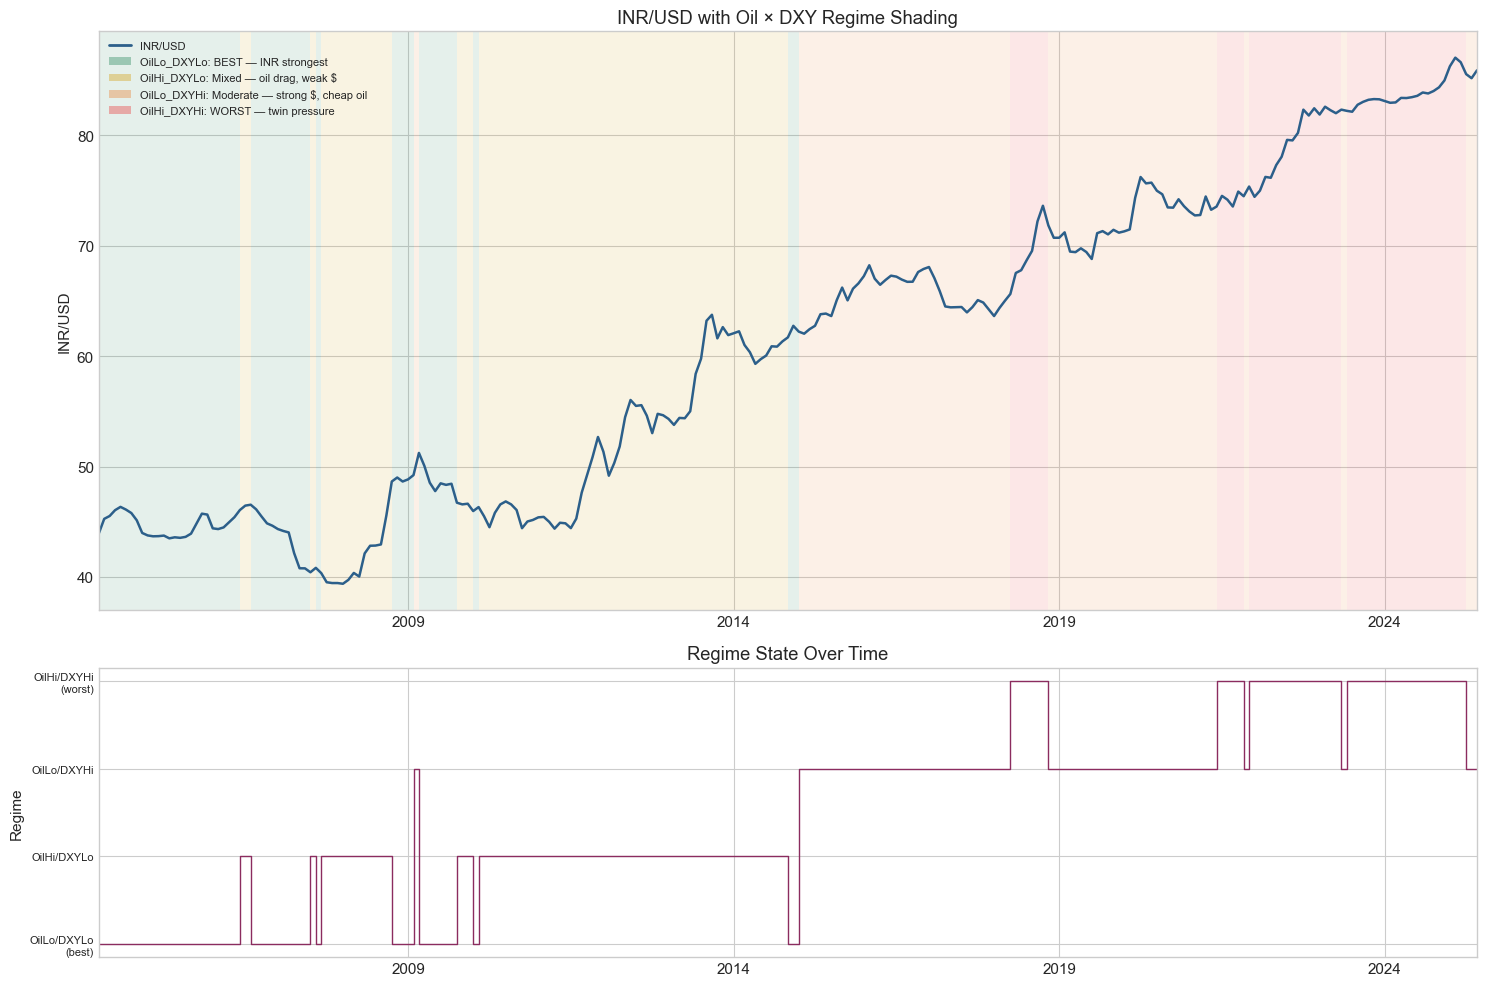


✓ Chart saved → outputs/04_regime_matrix.png

  Current regime (Jun 2025): OilLo_DXYHi


In [5]:
# ============================================================
# Phase 4 | Cell 4: Regime Matrix (Oil × DXY)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = model.copy()
df['inr_ret'] = np.log(df['inr_usd']).diff() * 100  # monthly % change

# ── Define high/low thresholds (median split) ────────────────
brent_med = df['brent'].median()
dxy_med   = df['dxy'].median()

print("=" * 60)
print("REGIME MATRIX — Oil × DXY")
print("=" * 60)
print(f"  Brent median (split): ${brent_med:.1f}/bbl")
print(f"  DXY median (split)  : {dxy_med:.1f}")

# ── Classify each month ───────────────────────────────────────
def classify(row):
    oil_hi = row['brent'] > brent_med
    dxy_hi = row['dxy']   > dxy_med
    if oil_hi and dxy_hi:   return 'OilHi_DXYHi'   # worst for INR
    if oil_hi and not dxy_hi: return 'OilHi_DXYLo'
    if not oil_hi and dxy_hi: return 'OilLo_DXYHi'
    return 'OilLo_DXYLo'                            # best for INR

df['oil_dxy_regime'] = df.apply(classify, axis=1)

# ── INR behaviour in each regime ─────────────────────────────
print(f"\n  INR/USD monthly return (%) by regime:")
print(f"  {'Regime':<16} {'N':>5} {'Mean Δ':>9} {'Std':>8} {'Interpretation'}")
print(f"  {'─'*62}")

regime_order = ['OilLo_DXYLo','OilHi_DXYLo','OilLo_DXYHi','OilHi_DXYHi']
regime_desc = {
    'OilLo_DXYLo': 'BEST — INR strongest',
    'OilHi_DXYLo': 'Mixed — oil drag, weak $',
    'OilLo_DXYHi': 'Moderate — strong $, cheap oil',
    'OilHi_DXYHi': 'WORST — twin pressure',
}
regime_stats = {}
for reg in regime_order:
    sub = df[df['oil_dxy_regime'] == reg]['inr_ret'].dropna()
    regime_stats[reg] = {'n': len(sub), 'mean': sub.mean(), 'std': sub.std()}
    print(f"  {reg:<16} {len(sub):>5} {sub.mean():>+8.2f}% {sub.std():>7.2f}%  "
          f"{regime_desc[reg]}")

print(f"\n  (Positive Δ = INR depreciating; negative = appreciating)")

# ── Validation: worst regime should show most depreciation ───
worst = regime_stats['OilHi_DXYHi']['mean']
best  = regime_stats['OilLo_DXYLo']['mean']
print(f"\n  Validation:")
print(f"    Twin-pressure regime mean: {worst:+.2f}%/mo "
      f"({'✓ depreciation' if worst > 0 else '⚠'})")
print(f"    Best regime mean:          {best:+.2f}%/mo "
      f"({'✓ appreciation/flat' if best < worst else '⚠'})")

# ── Plot: regime timeline + INR ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10),
                         gridspec_kw={'height_ratios':[2,1]})

ax = axes[0]
df['inr_usd'].plot(ax=ax, color='#2c5f8a', lw=1.8, label='INR/USD')
regime_colors = {
    'OilLo_DXYLo': '#2c8a5f',   # green - best
    'OilHi_DXYLo': '#d4a017',   # amber
    'OilLo_DXYHi': '#e8853a',   # orange
    'OilHi_DXYHi': '#e84040',   # red - worst
}
for reg, color in regime_colors.items():
    mask = df['oil_dxy_regime'] == reg
    for i in range(len(df)):
        if mask.iloc[i]:
            ax.axvspan(df.index[i], df.index[i] + pd.DateOffset(months=1),
                       alpha=0.12, color=color, lw=0)
ax.set_title('INR/USD with Oil × DXY Regime Shading')
ax.set_ylabel('INR/USD')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.4, label=f'{r}: {regime_desc[r]}')
                   for r, c in regime_colors.items()]
legend_elements.insert(0, plt.Line2D([0],[0], color='#2c5f8a', lw=2, label='INR/USD'))
ax.legend(handles=legend_elements, fontsize=8, loc='upper left')

ax = axes[1]
regime_num = {'OilLo_DXYLo':0,'OilHi_DXYLo':1,'OilLo_DXYHi':2,'OilHi_DXYHi':3}
df['regime_num'] = df['oil_dxy_regime'].map(regime_num)
df['regime_num'].plot(ax=ax, color='#8b2c5f', lw=1, drawstyle='steps-post')
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(['OilLo/DXYLo\n(best)','OilHi/DXYLo','OilLo/DXYHi','OilHi/DXYHi\n(worst)'],
                   fontsize=8)
ax.set_title('Regime State Over Time')
ax.set_ylabel('Regime')

plt.tight_layout()
plt.savefig('../outputs/04_regime_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved → outputs/04_regime_matrix.png")
print(f"\n  Current regime ({df.index[-1].strftime('%b %Y')}): "
      f"{df['oil_dxy_regime'].iloc[-1]}")

MARKOV-SWITCHING REGIME MODEL
  Sample: May 2004 → Jun 2025  (254 obs)
  Modeling: INR monthly returns with regime-switching mean + variance

  Model converged: True
  Log-likelihood: -462.60
  AIC: 937.19

  Regime characteristics:
    Regime 0: mean return = +0.056%/mo, std = 0.94%
    Regime 1: mean return = +0.724%/mo, std = 2.61%

  → Regime 1 = STRESS (high volatility)
  → Regime 0 = CALM (low volatility)

  TRANSITION PROBABILITY MATRIX (monthly):
                       → Calm   → Stress
    From Calm           0.876      0.272
    From Stress         0.124      0.728

  Expected regime duration:
    Calm:   8.1 months
    Stress: 3.7 months

  Current state (Jun 2025):
    P(stress) = 9.8%
    P(calm)   = 90.2%
    P(stress) in  3m = 52.8%
    P(stress) in  6m = 62.3%
    P(stress) in 12m = 64.8%


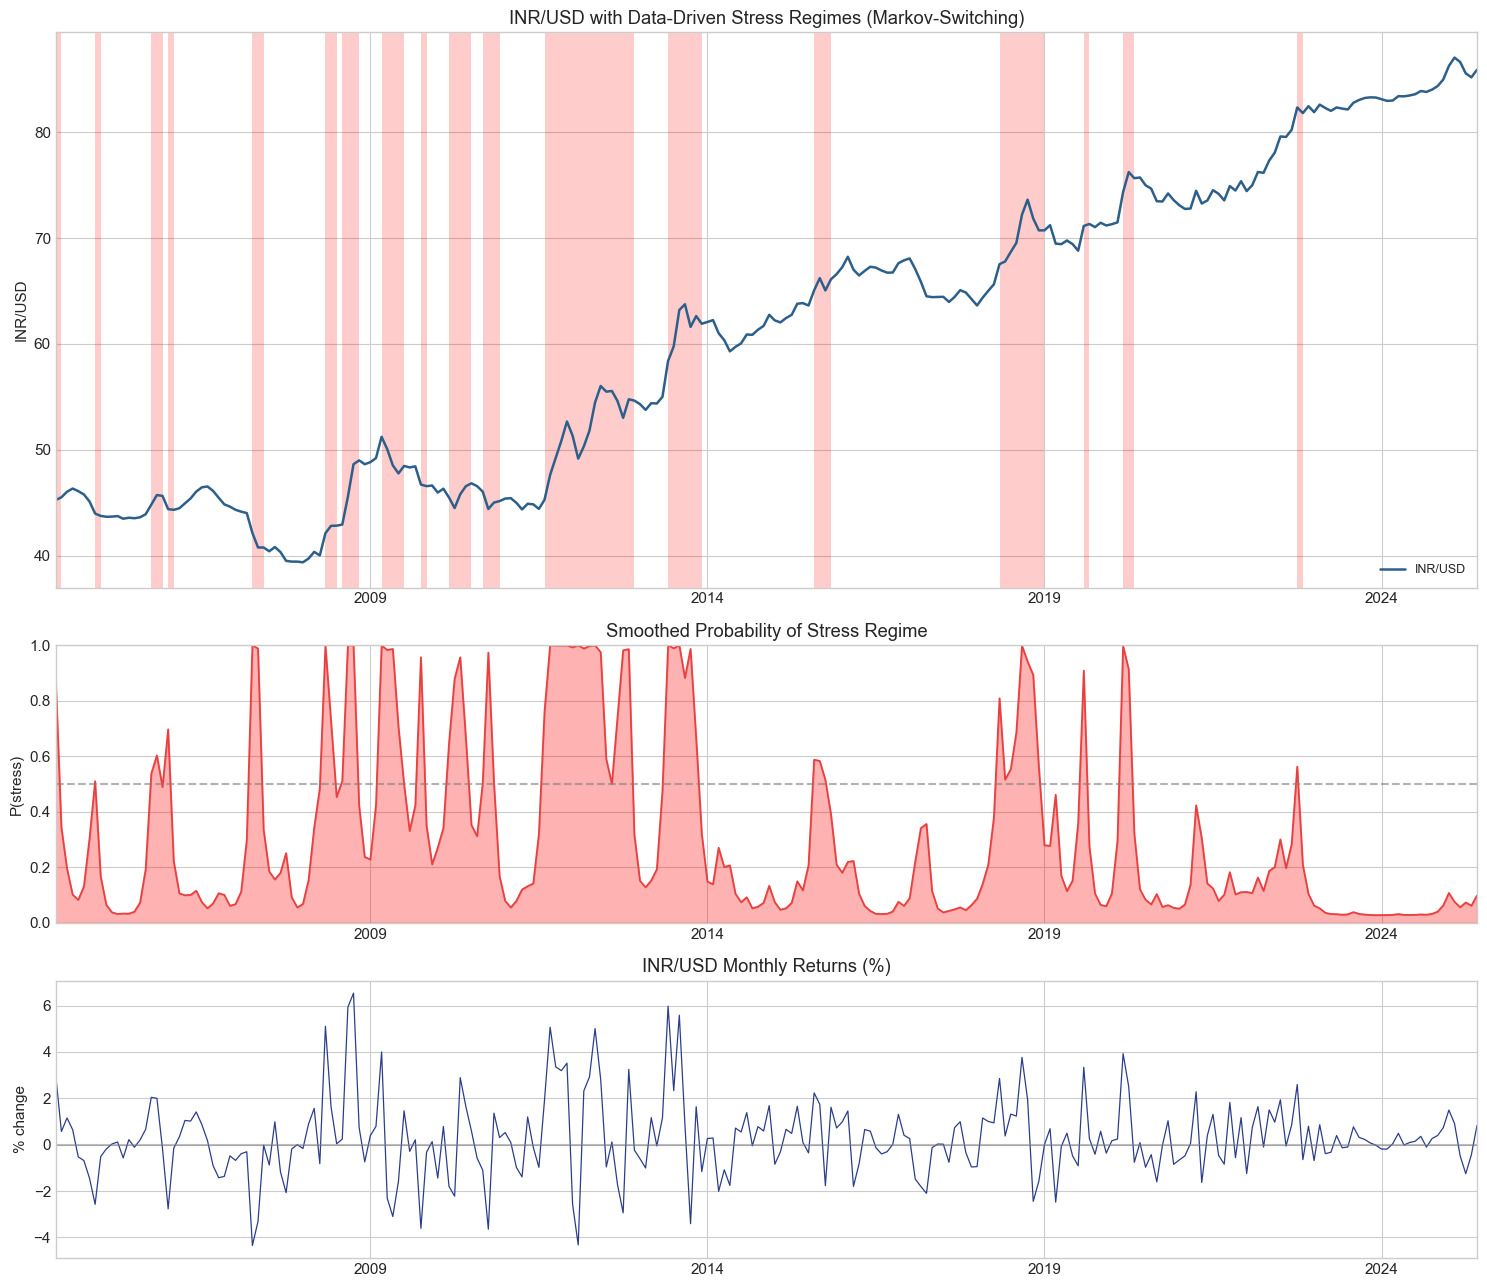


✓ Saved → data/processed/phase4_regimes.csv


In [6]:
# ============================================================
# Phase 4 | Cell 5: Markov-Switching Regime Detection
# Let the data find regimes endogenously
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

df = model.copy()
df['inr_ret'] = np.log(df['inr_usd']).diff() * 100   # monthly % change

# ── Markov-switching model on INR returns ─────────────────────
# 2 regimes: switching mean AND variance
# Regime 0 = calm (low vol), Regime 1 = stress (high vol)
ret = df['inr_ret'].dropna()

print("=" * 60)
print("MARKOV-SWITCHING REGIME MODEL")
print("=" * 60)
print(f"  Sample: {ret.index[0].strftime('%b %Y')} → "
      f"{ret.index[-1].strftime('%b %Y')}  ({len(ret)} obs)")
print(f"  Modeling: INR monthly returns with regime-switching mean + variance")

# Fit 2-regime model with switching variance
np.random.seed(42)
mod = MarkovRegression(ret, k_regimes=2, trend='c', switching_variance=True)
res = mod.fit(maxiter=200)

print(f"\n  Model converged: {res.mle_retvals['converged']}")
print(f"  Log-likelihood: {res.llf:.2f}")
print(f"  AIC: {res.aic:.2f}")

# ── Identify which regime is "stress" (higher variance) ──────
# params include const for each regime and sigma2 for each
regime_means = [res.params[f'const[{i}]'] for i in range(2)]
regime_vars  = [res.params[f'sigma2[{i}]'] for i in range(2)]

print(f"\n  Regime characteristics:")
for i in range(2):
    print(f"    Regime {i}: mean return = {regime_means[i]:+.3f}%/mo, "
          f"std = {np.sqrt(regime_vars[i]):.2f}%")

# Stress regime = higher variance
stress_regime = int(np.argmax(regime_vars))
calm_regime   = 1 - stress_regime
print(f"\n  → Regime {stress_regime} = STRESS (high volatility)")
print(f"  → Regime {calm_regime} = CALM (low volatility)")

# ── Smoothed regime probabilities ────────────────────────────
df_ret = pd.DataFrame(index=ret.index)
df_ret['prob_stress'] = res.smoothed_marginal_probabilities[stress_regime]
df_ret['prob_calm']   = res.smoothed_marginal_probabilities[calm_regime]
df_ret['inr_usd']     = df['inr_usd']
df_ret['inr_ret']     = ret

# ── Transition probability matrix ────────────────────────────
print(f"\n  TRANSITION PROBABILITY MATRIX (monthly):")
trans = res.regime_transition[:, :, 0]   # shape (k, k)
# Reorder so [calm, stress]
P = np.array([
    [trans[calm_regime, calm_regime],   trans[stress_regime, calm_regime]],
    [trans[calm_regime, stress_regime], trans[stress_regime, stress_regime]],
])
print(f"    {'':>14} {'→ Calm':>10} {'→ Stress':>10}")
print(f"    {'From Calm':<14} {P[0,0]:>10.3f} {P[1,0]:>10.3f}")
print(f"    {'From Stress':<14} {P[0,1]:>10.3f} {P[1,1]:>10.3f}")

# Expected duration in each regime
dur_calm   = 1 / (1 - trans[calm_regime, calm_regime])
dur_stress = 1 / (1 - trans[stress_regime, stress_regime])
print(f"\n  Expected regime duration:")
print(f"    Calm:   {dur_calm:.1f} months")
print(f"    Stress: {dur_stress:.1f} months")

# ── Current regime + 6-12 month transition probability ──────
current_stress_prob = df_ret['prob_stress'].iloc[-1]
print(f"\n  Current state ({ret.index[-1].strftime('%b %Y')}):")
print(f"    P(stress) = {current_stress_prob:.1%}")
print(f"    P(calm)   = {1-current_stress_prob:.1%}")

# Probability of being in stress in 6 months (matrix power)
P_trans = np.array([
    [trans[calm_regime, calm_regime],   trans[calm_regime, stress_regime]],
    [trans[stress_regime, calm_regime], trans[stress_regime, stress_regime]],
])
current_state = np.array([1-current_stress_prob, current_stress_prob])
for horizon in [3, 6, 12]:
    future = current_state @ np.linalg.matrix_power(P_trans, horizon)
    print(f"    P(stress) in {horizon:>2}m = {future[1]:.1%}")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 13),
                         gridspec_kw={'height_ratios':[2,1,1]})

ax = axes[0]
df_ret['inr_usd'].plot(ax=ax, color='#2c5f8a', lw=1.8, label='INR/USD')
# Shade stress periods (prob > 0.5)
stress_mask = df_ret['prob_stress'] > 0.5
for i in range(len(df_ret)):
    if stress_mask.iloc[i]:
        ax.axvspan(df_ret.index[i], df_ret.index[i]+pd.DateOffset(months=1),
                   alpha=0.2, color='red', lw=0)
ax.set_title('INR/USD with Data-Driven Stress Regimes (Markov-Switching)')
ax.set_ylabel('INR/USD')
ax.legend(fontsize=9)

ax = axes[1]
df_ret['prob_stress'].plot(ax=ax, color='#e84040', lw=1.3)
ax.fill_between(df_ret.index, df_ret['prob_stress'], 0, alpha=0.3, color='red')
ax.axhline(0.5, color='gray', ls='--', alpha=0.6)
ax.set_title('Smoothed Probability of Stress Regime')
ax.set_ylabel('P(stress)')
ax.set_ylim(0, 1)

ax = axes[2]
df_ret['inr_ret'].plot(ax=ax, color='#2c3e8a', lw=0.9)
ax.axhline(0, color='gray', ls='-', alpha=0.5)
ax.set_title('INR/USD Monthly Returns (%)')
ax.set_ylabel('% change')

plt.tight_layout()
plt.savefig('../outputs/04_markov_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────
df_ret[['inr_usd','inr_ret','prob_stress','prob_calm']].to_csv(
    f'{PROCESSED}phase4_regimes.csv')
print(f"\n✓ Saved → data/processed/phase4_regimes.csv")

PHASE 4 INTEGRATION + VALIDATION

  Validation: stress probability at known crisis dates
  Date        P(stress)  Episode
  ─────────────────────────────────────────────
  2008-11         42.3%  🟡 GFC peak
  2011-09        100.0%  🔴 EM pressure
  2013-08        100.0%  🔴 Taper tantrum
  2018-10         94.1%  🔴 EM selloff
  2020-03         99.7%  🔴 COVID crash
  2022-09         28.3%  🟡 Fed tightening
  2025-06          9.8%  🟢 Latest (calm)

  BEER misalignment: calm vs stress regimes
    Calm periods   : mean -0.1%, std 7.9%
    Stress periods : mean +1.7%, std 9.3%

  FOUR-MODEL CONVERGENCE (Jun 2025):
  Model                          Misalignment  Lens
  ────────────────────────────────────────────────────────
  Phase 2: REER structural              +4.1%  real competitiveness
  Phase 3: FEER sustainability          +7.4%  external balance
  Phase 4: BEER behavioral             +11.5%  market fundamentals


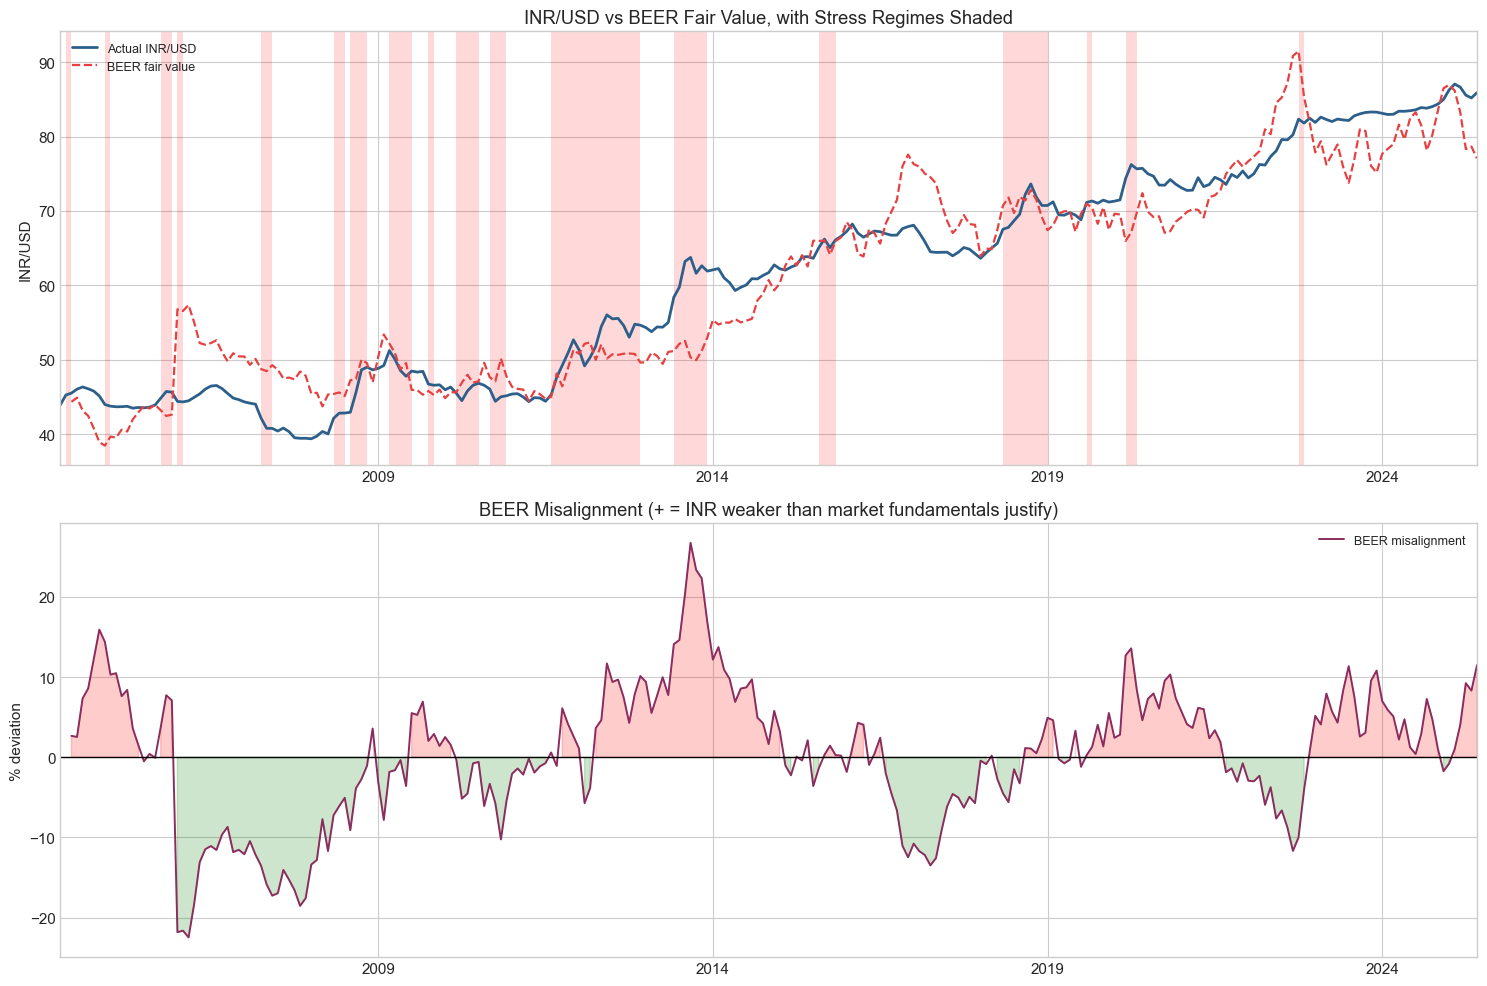


✓ Saved → data/processed/phase4_integrated.csv (253 months)


In [7]:
# ============================================================
# Phase 4 | Cell 6: Integration + Cross-Validation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load all Phase 4 pieces ───────────────────────────────────
beer    = pd.read_csv(f'{PROCESSED}phase4_beer.csv', index_col=0, parse_dates=True)
regimes = pd.read_csv(f'{PROCESSED}phase4_regimes.csv', index_col=0, parse_dates=True)
for d in (beer, regimes):
    d.index = pd.to_datetime(d.index).to_period('M').to_timestamp()

df = model.copy()
df = df.join(beer[['beer_inr_usd','beer_misalignment']])
df = df.join(regimes[['prob_stress']])

print("=" * 60)
print("PHASE 4 INTEGRATION + VALIDATION")
print("=" * 60)

# ── Validation 1: known crises should show high stress prob ──
print("\n  Validation: stress probability at known crisis dates")
print(f"  {'Date':<10} {'P(stress)':>10}  Episode")
print("  " + "─" * 45)
crises = {
    '2008-11-01': 'GFC peak',
    '2011-09-01': 'EM pressure',
    '2013-08-01': 'Taper tantrum',
    '2018-10-01': 'EM selloff',
    '2020-03-01': 'COVID crash',
    '2022-09-01': 'Fed tightening',
    '2025-06-01': 'Latest (calm)',
}
for date, desc in crises.items():
    try:
        p = df.loc[date, 'prob_stress']
        flag = '🔴' if p > 0.5 else '🟡' if p > 0.25 else '🟢'
        print(f"  {date[:7]:<10} {p:>10.1%}  {flag} {desc}")
    except: pass

# ── Validation 2: BEER misalignment by regime ────────────────
calm_mask = df['prob_stress'] < 0.5
print(f"\n  BEER misalignment: calm vs stress regimes")
print(f"    Calm periods   : mean {df[calm_mask]['beer_misalignment'].mean():+.1f}%, "
      f"std {df[calm_mask]['beer_misalignment'].std():.1f}%")
print(f"    Stress periods : mean {df[~calm_mask]['beer_misalignment'].mean():+.1f}%, "
      f"std {df[~calm_mask]['beer_misalignment'].std():.1f}%")

# ── Summary: all four model misalignments side by side ───────
phase2 = pd.read_csv(f'{PROCESSED}phase2_equilibrium.csv', index_col=0, parse_dates=True)
phase3 = pd.read_csv(f'{PROCESSED}phase3_feer.csv', index_col=0, parse_dates=True)
for d in (phase2, phase3):
    d.index = pd.to_datetime(d.index).to_period('M').to_timestamp()

latest = df.index[-1]
print(f"\n  FOUR-MODEL CONVERGENCE ({latest.strftime('%b %Y')}):")
print(f"  {'Model':<28} {'Misalignment':>14}  Lens")
print("  " + "─" * 56)
print(f"  {'Phase 2: REER structural':<28} "
      f"{phase2['reer_misalignment_pct'].iloc[-1]:>+13.1f}%  real competitiveness")
print(f"  {'Phase 3: FEER sustainability':<28} "
      f"{phase3['feer_misalignment'].iloc[-1]:>+13.1f}%  external balance")
print(f"  {'Phase 4: BEER behavioral':<28} "
      f"{df['beer_misalignment'].iloc[-1]:>+13.1f}%  market fundamentals")

# ── Final integrated chart ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

ax = axes[0]
df['inr_usd'].plot(ax=ax, color='#2c5f8a', lw=2, label='Actual INR/USD')
df['beer_inr_usd'].plot(ax=ax, color='#e84040', lw=1.6, ls='--', label='BEER fair value')
stress_mask = df['prob_stress'] > 0.5
for i in range(len(df)):
    if stress_mask.iloc[i]:
        ax.axvspan(df.index[i], df.index[i]+pd.DateOffset(months=1),
                   alpha=0.15, color='red', lw=0)
ax.set_title('INR/USD vs BEER Fair Value, with Stress Regimes Shaded')
ax.set_ylabel('INR/USD')
ax.legend(fontsize=9, loc='upper left')

ax = axes[1]
df['beer_misalignment'].plot(ax=ax, color='#8b2c5f', lw=1.4, label='BEER misalignment')
ax.axhline(0, color='black', lw=1)
ax.fill_between(df.index, df['beer_misalignment'], 0,
                where=df['beer_misalignment']>0, alpha=0.2, color='red')
ax.fill_between(df.index, df['beer_misalignment'], 0,
                where=df['beer_misalignment']<0, alpha=0.2, color='green')
ax.set_title('BEER Misalignment (+ = INR weaker than market fundamentals justify)')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/04_phase4_integration.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save integrated Phase 4 output ───────────────────────────
out = df[['inr_usd','beer_inr_usd','beer_misalignment','prob_stress']].dropna()
out.to_csv(f'{PROCESSED}phase4_integrated.csv')
print(f"\n✓ Saved → data/processed/phase4_integrated.csv ({len(out)} months)")